<a href="https://colab.research.google.com/github/bungalunnac/Pembelajaran_mesin/blob/main/Data%20dan%20Preprocessing/13-Transformasi%20data/transformasiData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
<h2>Daftar Isi: </h2>
<h3>Transformasi Data</h3>
<h5>Imputasi:</h5>
    <ol>
    <li>Imputasi Mean atau Median</li>
    <li>Imputasi Nilai Suka-suka (Arbitrary)</li>
        Imputasi End of Tail
        Imputasi Frequent Category/Modus
        Imputasi Random Sample
        Imputasi Nilai Nol/Konstanta
        Imputasi Regresi: Deterministik
    </ol>
<h5>Trimming vs Winsorizing</h5>
<h5>Binning</h5>
<h5>Scaling (Penskalaan):</h5>
     <ol>
        <li>Scaling: Normalisasi</li>
        <li>Scaling: Standardisasi</li>
     </ol>
</div>

# Mengkonstruksi Data
---

## Imputasi
---

Imputasi adalah Mengganti nilai/data yang hilang (missing value; NaN; blank) dengan nilai pengganti.

Teknik imputasi berdasarkan tipe data, terdiri dari:
1. Tipe data Variabel Numerik, dengan cara:
   - Imputasi mean atau median.
   - Imputasi nilai suka-suka (arbitrary).
   - Imputasi nilai/data ujung (end of tail).


2. Tipe data Variabel Kategorik, dengan cara:
   - Imputasi kategori yang sering muncul.
   - Tambah kategori yang hilang.

### Imputasi Mean atau Median
___

Merupakan teknik yang digunakan mengganti nilai/data yang hilang untuk tipe data numerik, dan cocok untuk data missing completely at random (MCAR).

In [117]:
#Import pandas dan numpy

import pandas as pd
import numpy as np

Mengawali Hands-On ini, import library Pandas dan library Numpy telah dilakukan diawal, sehingga pada contoh-contoh code dibawah, sudah tidak dilakukan import library Pandas dan library Numpy.

In [118]:
#Contoh 1 - Imputasi MEAN
#Masukkan data

kolom = {'col1' : [2, 9, 19],
        'col2' : [5, np.nan, 17],
        'col3' : [3, 9, np.nan],
        'col4' : [6, 0, 9],
        'col5' : [np.nan, 7, np.nan]}

data = pd.DataFrame(kolom)

#pd.DataFrame() --> fungsi mengubah menjadi dataframe

In [119]:
#Contoh 1 - Imputasi MEAN
#Tampilkan nilai yang ada pada variabel 'kolom' dalam bentuk dataframe 'data'

data

,col1,col2,col3,col4,col5
0,2,5.0,3.0,6,NaN
1,9,NaN,9.0,0,7.0
2,19,17.0,NaN,9,NaN


Tampak pada variabel 'kolom' terdapat data yang hilang (NaN), misal pada baris di indeks=1 kolom=col2. Maka nilai yang hilang (NaN) dapat diberikan nilai, salah satunya dengan menggunakan teknik imputasi MEAN.

In [120]:
#Contoh 1 - Imputasi MEAN
# Mengganti missing value dengan mean()

data.fillna(data.mean())

,col1,col2,col3,col4,col5
0,2,5.0,3.0,6,7.0
1,9,11.0,9.0,0,7.0
2,19,17.0,6.0,9,7.0


Setelah dilakukan imputasi MEAN, terlihat pada data baris di indeks=1 kolom=col2 telah terisi nilai yang didapatkan dari nilai mean (rata-rata).

In [121]:
#Contoh 2 - Imputasi MEAN
#Masukkan data

umur = {'umur' : [29, 43,  np.nan, 25, 34, np.nan, 50]}

#Ubah ke dataframe

data = pd.DataFrame(umur)

#Tampilkan nilai yang ada pada variabel 'umur' dalam bentuk dataframe 'data'

data

,umur
0,29.0
1,43.0
2,NaN
3,25.0
4,34.0
5,NaN
6,50.0


Tampak pada variabel 'umur' terdapat data yang hilang (NaN), misal umur yang ada pada baris di indeks= 2. Maka nilai yang hilang (NaN) dapat diberikan nilai, salah satunya dengan menggunakan teknik imputasi MEAN.

In [122]:
#Contoh 2 - Imputasi MEAN
#Mengganti missing value dengan mean pada kolom umur

data.fillna(data.mean())

#data.fillna() --> fungsi mengganti missing value

,umur
0,29.0
1,43.0
2,36.2
3,25.0
4,34.0
5,36.2
6,50.0


Setelah dilakukan imputasi MEAN, pada data umur yang ada pada baris di indeks= 2 telah memiliki nilai yang diperoleh dari nilai mean (rata-rata)

### Imputasi Nilai Suka-suka (Arbitrary)
---

Imputasi nilai suka-suka (Arbitrary) juga merupakan salah satu teknik imputasi yang dapat digunakan untuk menggantikan nilai/data yang hilang. Teknik ini juga cocok untuk digunakan bagi tipe data numerik.

In [123]:
#Contoh 1 - Imputasi ARBITRARY
#Masukkan  data

umur = {'umur' : [29, 43,  np.nan, 25, 34, np.nan, 50]}

#Ubah ke dataframe

data = pd.DataFrame(umur)

#Tampilkan nilai yang ada pada variabel 'umur' dalam bentuk dataframe 'data'

data

,umur
0,29.0
1,43.0
2,NaN
3,25.0
4,34.0
5,NaN
6,50.0


Tampak pada variabel 'umur' terdapat nilai yang hilang (NaN), misalkan nilai umur yang ada pada baris di indeks= 2.

In [124]:
#Contoh 1 - Imputasi ARBITRARY
#Mengatasi nilai missing value dengan imputasi suka-suka
#Nilai suka-suka yang diberikan pada contoh adalah 99

data.fillna(99)

,umur
0,29.0
1,43.0
2,99.0
3,25.0
4,34.0
5,99.0
6,50.0


Setelah dilakukan imputasi ARBITRARY, data umur pada baris 2 telah memiliki nilai yaitu 99, sesuai dengan nilai suka-suka yang telah diberikan.

### Imputasi End of Tail

Imputasi End of Tail juga termasuk salah satu teknik untuk mengganti data/nilai yang hilang dan digunakan untuk tipe data numerik.

In [125]:
#Contoh 1 - Imputasi END OF TAIL
#masukkan data

umur = {'umur' : [29, 43,  np.nan, 25, 34, np.nan, 50]}

#Data dalam bentuk dataframe
data = pd.DataFrame(umur)

#Tampilkan nilai pada variabel 'umur' dalam bentuk dataframe

data

,umur
0,29.0
1,43.0
2,NaN
3,25.0
4,34.0
5,NaN
6,50.0


Tampak pada variabel 'umur' terdapat nilai yang hilang (NaN), misalkan nilai umur yang ada pada baris di indeks= 2.

In [126]:
!pip install feature_engine

In [127]:
#Contoh 1 - Imputasi END OF TAIL
#Import EndTailImputer

from feature_engine.imputation import EndTailImputer

#Membuat imputer
imputer = EndTailImputer(imputation_method='gaussian', tail='right')

#Fit imputer ke set
imputer.fit(data)

#Mengubah data
test_t = imputer.transform(data)

In [128]:
#Contoh 1 - Imputasi END OF TAIL
#Tampilkan data

test_t

,umur
0,29.000000
1,43.000000
2,66.896905
3,25.000000
4,34.000000
5,66.896905
6,50.000000


Setelah dilakukan imputasi, nilai umur yang ada pada baris di indeks= 2 sudah terisi dengan nilai.

### Imputasi Frequent Category/Modus

Imputasi frequent category/Modus merupakan teknik untuk menggantikan nilai/data hilang dan digunakan bagi tipe data kategori.Cocok untuk data dengan missing at random.

In [129]:
#Contoh 1 - Imputasi Frequent Category/Modus
#Import SimpleImputer dari sklearn.impute

from sklearn.impute import SimpleImputer

In [130]:
#Contoh 1 - Imputasi Frequent Category/Modus
#Masukkan data

make = {'make' : ['Ford', 'Ford', 'Fiat', 'BMW', 'Ford', 'Kia', np.nan, 'Fiat', 'Ford', np.nan, 'Kia']}

#Ubah menjadi dataframe

data = pd.DataFrame(make)

#Tampilkan nilai variabel 'make' dalam bentuk dataframe

data

,make
0,Ford
1,Ford
2,Fiat
3,BMW
4,Ford
5,Kia
6,NaN
7,Fiat
8,Ford
9,NaN


Tampak pada variabel 'make' terdapat nilai yang hilang (NaN), misalkan nilai yang ada pada baris di indeks= 6.

In [131]:
#Contoh 1 - Imputasi Frequent Category/Modus
#Mengatasi missing value dengan frequent category / modus

imp = SimpleImputer(strategy='most_frequent')

In [132]:
#Contoh 1 - Imputasi Frequent Category/Modus
#Tampilkan hasil imputasi

imp.fit_transform(data)

array([['Ford'],
       ['Ford'],
       ['Fiat'],
       ['BMW'],
       ['Ford'],
       ['Kia'],
       ['Ford'],
       ['Fiat'],
       ['Ford'],
       ['Ford'],
       ['Kia']], dtype=object)

Setelah dilakukan imputasi, variabel 'make' pada baris di indeks= 6 telah terisi dengan nilai yang merupakan nilai modus dari data tersebut.

### Imputasi Random Sample

Imputasi Random Sample merupakan teknik untuk menggantikan nilai/data hilang dan digunakan bagi tipe data kategori. Cocok untuk data missing at random. Imputasi ini menggantikan missing value dengan nilai lain dalam distribusi yang sama dari variabel asli.

In [133]:
#Contoh 1 - Imputasi Random Sample
#Import randomsample imputer

from feature_engine.imputation import RandomSampleImputer

# masukkan data dan ubah menjadi dataframe

data = {'Gender' : ['Male', 'Male', np.nan, 'Female', 'Male', np.nan, 'Female'],
       'Age' : [29, np.nan, 43, 25, 34, 50, np.nan]}

#Data dalam bentuk dataframe

df = pd.DataFrame(data)

#Tampilkan data dalam bentuk dataframe
df

,Gender,Age
0,Male,29.0
1,Male,NaN
2,NaN,43.0
3,Female,25.0
4,Male,34.0
5,NaN,50.0
6,Female,NaN


Pada data, tampak nilai yang hilang, misalkan pada data baris dengan indeks= 1 dan di kolom Age.

In [134]:
#Contoh 1 - Imputasi Random Sample
#Buat imputernya
imputer = RandomSampleImputer(random_state = 29)

#Fit imputer ke set
imputer.fit(df)

#Mengubah data
test_t = imputer.transform(df)


In [135]:
#Contoh 1 - Imputasi Random Sample
#Tampilkan data hasil imputasi

test_t

,Gender,Age
0,Male,29.0
1,Male,34.0
2,Male,43.0
3,Female,25.0
4,Male,34.0
5,Female,50.0
6,Female,50.0


Setelah dilakukan imputasi, tampak pada baris di indeks= 1 dan di kolom Age telah memiliki nilai.

### Imputasi Nilai Nol/Konstanta

Cara lain yang dapat dilakukan untuk menggantikan nilai yang hilang adalah dengan imputasi nilai nol/konstanta. Teknik ini cocok untuk variabel kategorik.

In [136]:
#Contoh 1 - Imputasi Nilai Nol/Konstanta
#Masukkan  data

umur = {'umur' : [29, 43,  np.nan, 25, 34, np.nan, 50]}

#Ubah ke dataframe

data = pd.DataFrame(umur)

#Tampilkan nilai yang ada pada variabel 'umur' dalam bentuk dataframe 'data'

data

,umur
0,29.0
1,43.0
2,NaN
3,25.0
4,34.0
5,NaN
6,50.0


Tampak pada variabel 'umur' terdapat nilai yang hilang (NaN), misalkan nilai umur yang ada pada baris di indeks= 2.

In [137]:
#Contoh 1 - Imputasi Nilai Nol/Konstanta
#Mengatasi nilai missing value dengan imputasi suka-suka
#Nilai suka-suka yang diberikan pada contoh adalah 99

data.fillna(0)

,umur
0,29.0
1,43.0
2,0.0
3,25.0
4,34.0
5,0.0
6,50.0


Setelah dilakukan imputasi nilai nol, data umur pada baris 2 telah memiliki nilai yaitu 0 (nol)

### Imputasi Regresi: Deterministik
**Sumber** : kaggle

Imputasi regresi deterministik adalah teknik mengganti missing value dengan prediksi yang tepat dari model regresi. Teknik ini tidak mempertimbangkan variasi acak di sekitar kemiringan (slope regresi).

Lengkapi library seperti matplotlib, seaborn, missingno, dan sklearn
Jika belum terinstall di Python, maka lakukan instalasi library terlebih dahulu.

<div class="alert alert-block alert-danger">
<b>Catatan : </b>Jika belum pernah instal library, gunakan perintah berikut secara inline atau melalui terminal.
    <ol>
    <li>!pip install matplotlib</li>
    <li>!pip install seaborn</li>
    <li>!pip install missingno</li>
    </ol>
</div>

In [138]:
#Import library

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno
from sklearn import linear_model

%matplotlib inline


**Fungsi: %matplotlib inline**

digunakan agar output dari perintah plotting ditampilkan inline di dalam frontend seperti notebook Jupyter, tepat di bawah sel kode yang memproduksinya. Plot yang dihasilkan kemudian akan disimpan dalam dokumen notebook.

In [139]:
#Menentukan nilai yang hilang
#Memuat dataset dengan nama diabetes.csv

df = pd.read_csv("diabetes.csv")

#Tampilkan data teratas sebanyak 3 (tiga) baris data

df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [140]:
#Melihat info dari dataset diabetes.csv

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [141]:
#Menghitung nilai statistik

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [142]:
#Memilih kolom tertentu berdasarkan lokasi
#Fungsi df.loc[] digunakan untuk memilih table berdasarkan lokasi
#Nilai pada kolom 0.0 merupakan missing value (NaN)

df.loc[df["Glucose"] == 0.0, "Glucose"] = np.nan
df.loc[df["BloodPressure"] == 0.0, "BloodPressure"] = np.nan
df.loc[df["SkinThickness"] == 0.0, "SkinThickness"] = np.nan
df.loc[df["Insulin"] == 0.0, "Insulin"] = np.nan
df.loc[df["BMI"] == 0.0, "BMI"] = np.nan

#Menghitung nilai null dari dataframe, dan hanya 5 (lima) kolom dengan menambahkan [1:6]

df.isnull().sum()[1:6]


,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


<Axes: >

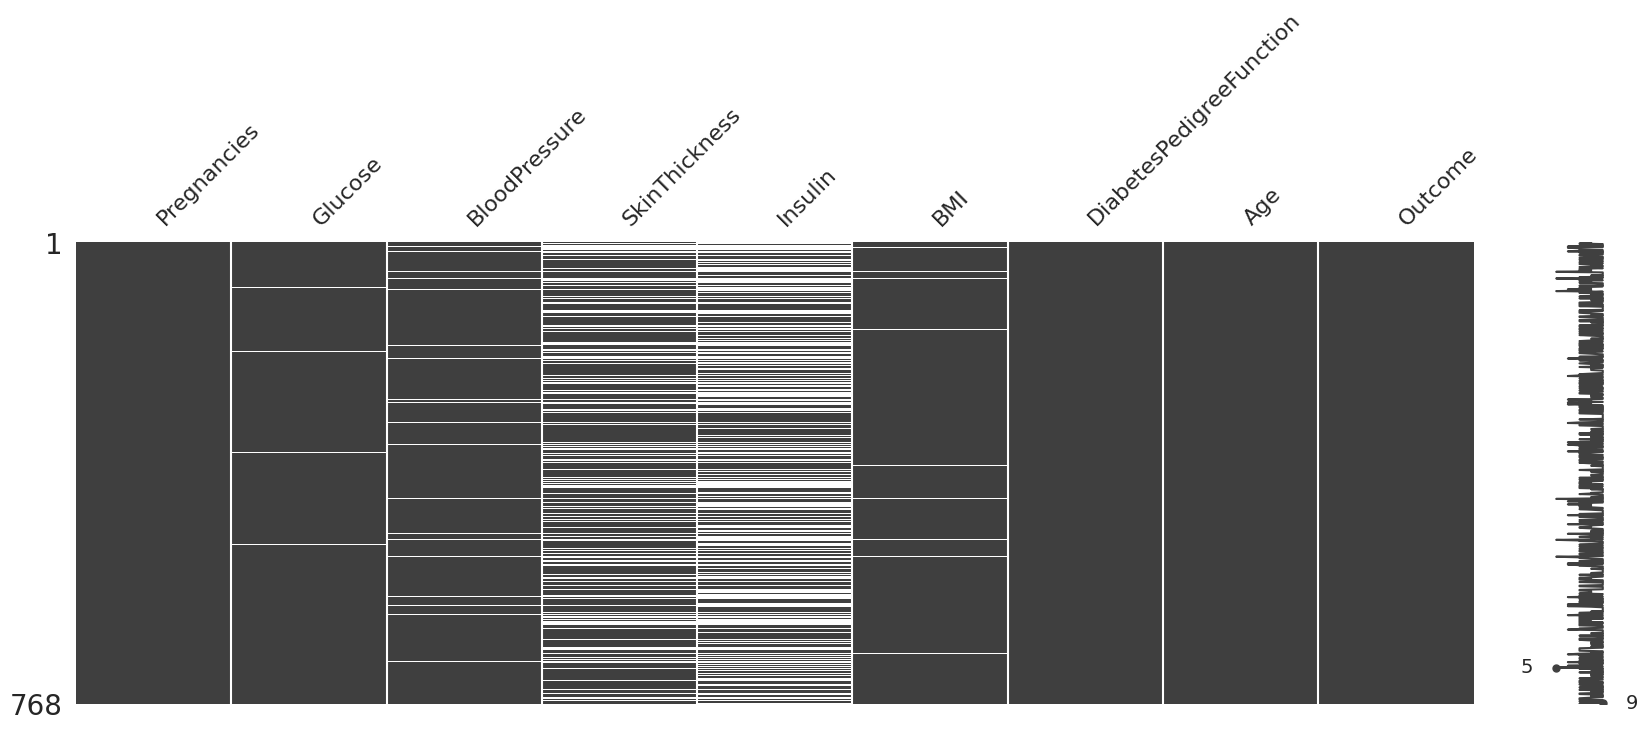

In [143]:
#Membuat matriks dengan ukuran yang diinginkan

mno.matrix(df, figsize = (20, 6))

#Fungsi figsize digunakan untuk menentukan ukuran figure

In [144]:
#Menggunakan Regresi untuk memperhitungkan data yang hilang
#Kolom dapat ditentukan berdasarkan kebutuhan

missing_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

In [145]:
def random_imputation(df, feature):

    number_missing = df[feature].isnull().sum()
    observed_values = df.loc[df[feature].notnull(), feature]
    df.loc[df[feature].isnull(), feature + '_imp'] = np.random.choice(observed_values, number_missing, replace = True)

    return df

In [146]:
for feature in missing_columns:
    df[feature + '_imp'] = df[feature]
    df = random_imputation(df, feature)

In [147]:
# Deterministic Regression Imputation

deter_data = pd.DataFrame(columns = ["Det" + name for name in missing_columns])

for feature in missing_columns:

    deter_data["Det" + feature] = df[feature + "_imp"]
    parameters = list(set(df.columns) - set(missing_columns) - {feature + '_imp'})

    # Buat model Regresi Linier untuk memperkirakan data yang hilang

    model = linear_model.LinearRegression()
    model.fit(X = df[parameters], y = df[feature + '_imp'])

    # amati bahwa kita menyimpan indeks data yang hilang dari kerangka data asli

    deter_data.loc[df[feature].isnull(), "Det" + feature] = model.predict(df[parameters])[df[feature].isnull()]

<Axes: >

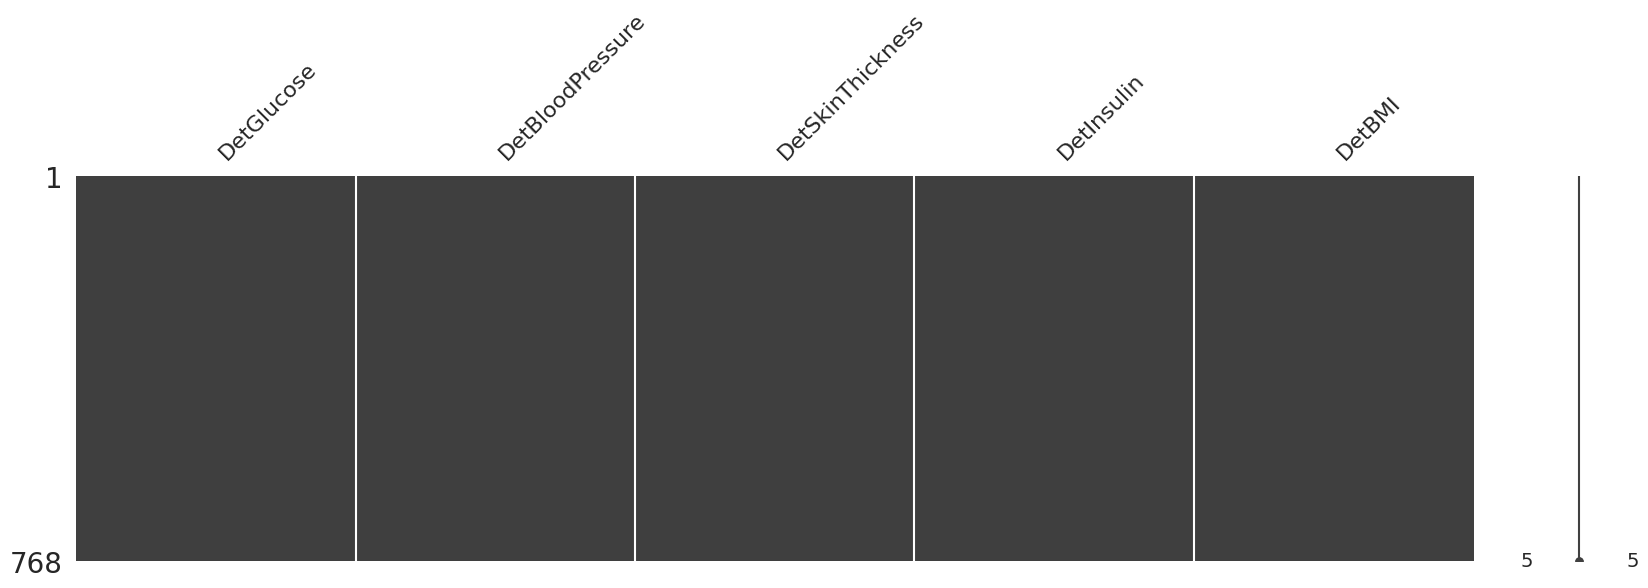

In [148]:
# membuat matriks

mno.matrix(deter_data, figsize = (20,5))

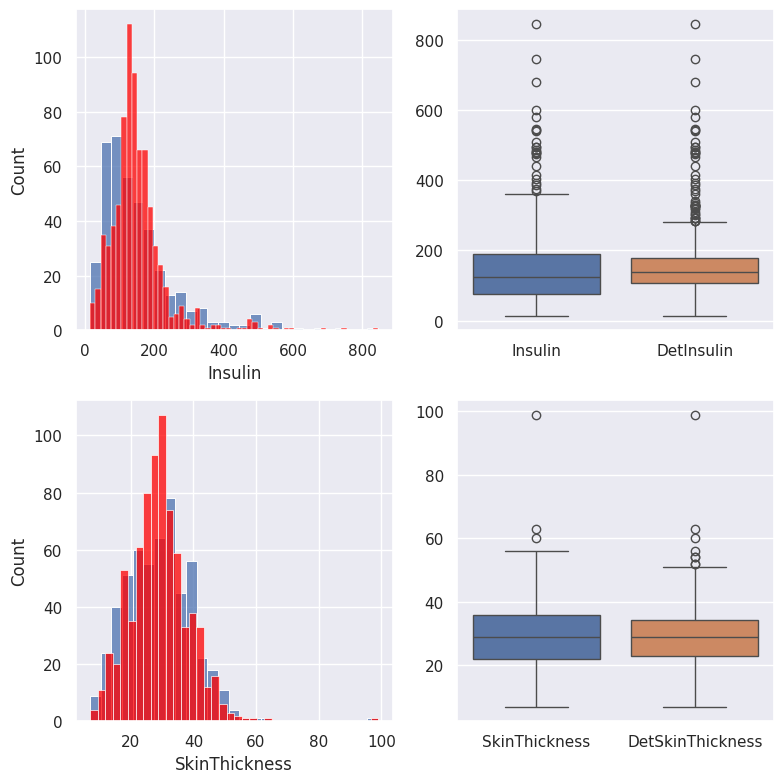

In [149]:
# membuat chart

sns.set()
fig, axes = plt.subplots(nrows = 2, ncols = 2)
fig.set_size_inches(8, 8)

for index, variable in enumerate(["Insulin", "SkinThickness"]):
    sns.histplot(df[variable].dropna(), kde = False, ax = axes[index, 0])
    sns.histplot(deter_data["Det" + variable], kde = False, ax = axes[index, 0], color = 'red')

    sns.boxplot(data = pd.concat([df[variable], deter_data["Det" + variable]], axis = 1),
                ax = axes[index, 1])

plt.tight_layout()

In [150]:
#Tampilkan nilai perhitungan statistika untuk kolom tertentu

pd.concat([df[["Insulin", "SkinThickness"]], deter_data[["DetInsulin", "DetSkinThickness"]]], axis = 1).describe().T

,count,mean,std,min,25%,50%,75%,max
Insulin,394.0,155.548223,118.775855,14.0,76.250000,125.000000,190.000000,846.0
SkinThickness,541.0,29.153420,10.476982,7.0,22.000000,29.000000,36.000000,99.0
DetInsulin,768.0,152.607626,88.348042,14.0,107.151971,138.772050,177.354096,846.0
DetSkinThickness,768.0,29.010998,9.165986,7.0,23.000000,28.901503,34.344687,99.0


### Imputasi Regresi: Stokastik
**Sumber** : kaggle

Menambahkan fitur “random error” sehingga reproduksi korelasi X-Y lebih tepat.

In [151]:
#Import library

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno
from sklearn import linear_model

%matplotlib inline

In [152]:
#Menentukan nilai yang hilang

df = pd.read_csv("diabetes.csv")
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [153]:
#Melihat info dari data frame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [154]:
#Menghitung data statistik

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [155]:
#Memilih kolom tertentu berdasarkan lokasi
#Fungsi df.loc[] digunakan untuk memilih table berdasarkan lokasi
#Nilai pada kolom 0.0 merupakan missing value (NaN)

df.loc[df["Glucose"] == 0.0, "Glucose"] = np.nan
df.loc[df["BloodPressure"] == 0.0, "BloodPressure"] = np.nan
df.loc[df["SkinThickness"] == 0.0, "SkinThickness"] = np.nan
df.loc[df["Insulin"] == 0.0, "Insulin"] = np.nan
df.loc[df["BMI"] == 0.0, "BMI"] = np.nan

#Menghitung nilai null dari dataframe, dan hanya 5 (lima) kolom dengan menambahkan [1:6]

df.isnull().sum()[1:6]


,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


<Axes: >

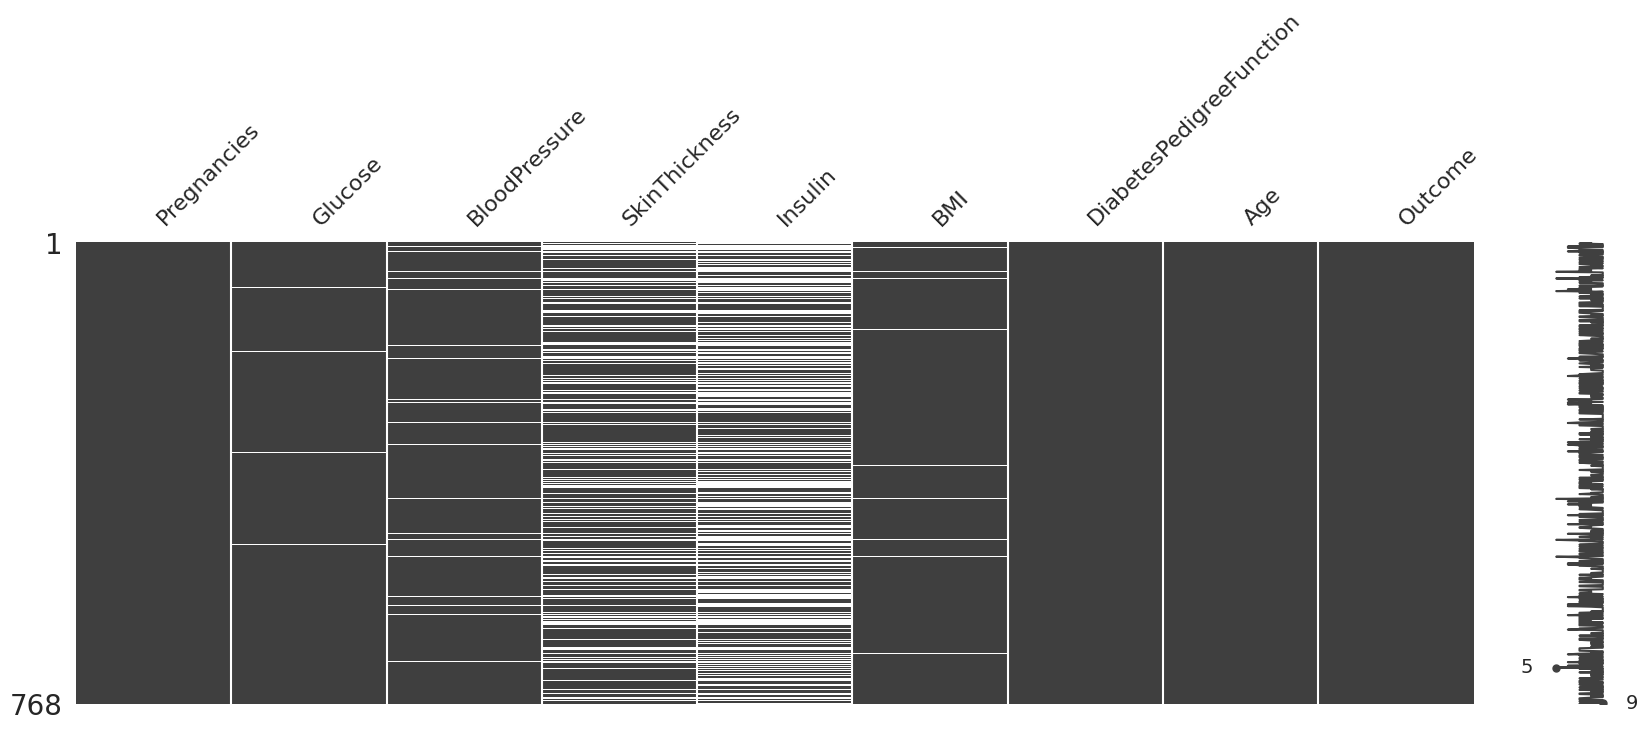

In [156]:
# membuat matriks

mno.matrix(df, figsize = (20, 6))

In [157]:
#Menggunakan Regresi untuk memperhitungkan data yang hilang
#Memilih kolom tertentu

missing_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

In [158]:
def random_imputation(df, feature):

    number_missing = df[feature].isnull().sum()
    observed_values = df.loc[df[feature].notnull(), feature]
    df.loc[df[feature].isnull(), feature + '_imp'] = np.random.choice(observed_values, number_missing, replace = True)

    return df

In [159]:
for feature in missing_columns:
    df[feature + '_imp'] = df[feature]
    df = random_imputation(df, feature)

In [160]:
#Stochastic Regression Imputation

random_data = pd.DataFrame(columns = ["Ran" + name for name in missing_columns])

for feature in missing_columns:

    random_data["Ran" + feature] = df[feature + '_imp']
    parameters = list(set(df.columns) - set(missing_columns) - {feature + '_imp'})

    model = linear_model.LinearRegression()
    model.fit(X = df[parameters], y = df[feature + '_imp'])

    #Kesalahan Standar dari perkiraan regresi sama dengan std() dari kesalahan setiap perkiraan

    predict = model.predict(df[parameters])
    std_error = (predict[df[feature].notnull()] - df.loc[df[feature].notnull(), feature + '_imp']).std()

    #Amati bahwa kita menyimpan indeks data yang hilang dari kerangka data asli
    random_predict = np.random.normal(size = df[feature].shape[0],
                                      loc = predict,
                                      scale = std_error)
    random_data.loc[(df[feature].isnull()) & (random_predict > 0), "Ran" + feature] = random_predict[(df[feature].isnull()) &
                                                                            (random_predict > 0)]

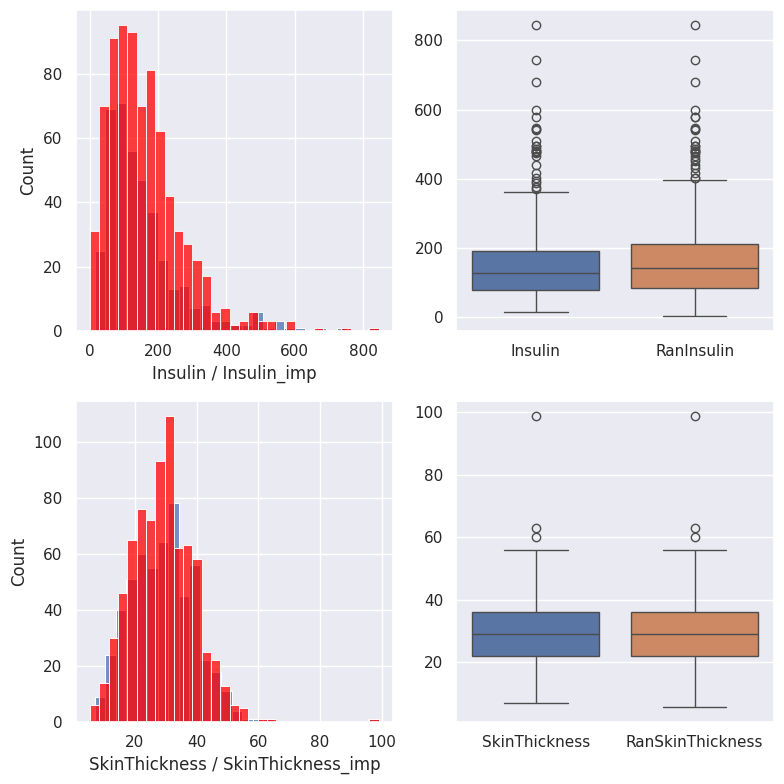

In [161]:
#Membuat chart

sns.set()
fig, axes = plt.subplots(nrows = 2, ncols = 2)
fig.set_size_inches(8, 8)

for index, variable in enumerate(["Insulin", "SkinThickness"]):
    sns.histplot(df[variable].dropna(), kde = False, ax = axes[index, 0])
    sns.histplot(random_data["Ran" + variable], kde = False, ax = axes[index, 0], color = 'red')
    axes[index, 0].set(xlabel = variable + " / " + variable + '_imp')

    sns.boxplot(data = pd.concat([df[variable], random_data["Ran" + variable]], axis = 1),
                ax = axes[index, 1])

    plt.tight_layout()

In [162]:
#Tampilkan nilai perhitungan statistika untuk kolom tertentu

pd.concat([df[["Insulin", "SkinThickness"]], random_data[["RanInsulin", "RanSkinThickness"]]], axis = 1).describe().T

,count,mean,std,min,25%,50%,75%,max
Insulin,394.0,155.548223,118.775855,14.000000,76.250000,125.0,190.0,846.0
SkinThickness,541.0,29.153420,10.476982,7.000000,22.000000,29.0,36.0,99.0
RanInsulin,768.0,160.777310,109.399470,0.613872,82.529224,140.0,210.0,846.0
RanSkinThickness,768.0,29.062657,10.073990,5.457167,22.000000,29.0,36.0,99.0


## Trimming vs Winsorizing
---

Trimming adalah teknik untuk menghapus outlier dari dataset.
Windsorizing adalah mengganti outlier dari dataset dengan nilai persentil setiap ujung/batas atas dan bawah.

In [163]:
#Import library scipy

import numpy as np
from scipy.stats.mstats import winsorize
from scipy.stats.mstats import trima

# Masukkan array berisi 1 - 10

a = np.array([10, 4, 9, 8, 5, 3, 7, 2, 1, 6])

In [164]:
#Winsorize akan mengganti 10% nilai terendah dan 20% nilai tinggi

wins = winsorize(a, limits=[0.1, 0.2])
wins

masked_array(data=[8, 4, 8, 8, 5, 3, 7, 2, 2, 6],
             mask=False,
       fill_value=999999)

In [165]:
#Trima akan memotong nilai dengan batas tertentu

trims = trima(a, limits=(2,8))
print(trims)

[-- 4 -- 8 5 3 7 2 -- 6]


## Binning
---

Proses mengubah fungsi, model dan variabel kontinu menjadi diskret (data kontinu di Ukur (measured), data kontinu di Hitung (counted)).

In [166]:
#Load/muat dataset dengan nama bins.csv

df = pd.read_csv('bins.csv')

#Tampilkan isi dataset
df

,Item,Harga
0,Item_1,1500
1,Item_2,3300
2,Item_3,11000
3,Item_4,87500
4,Item_5,45000
5,Item_6,28600
6,Item_7,39900
7,Item_8,91000
8,Item_9,64700
9,Item_10,6000


In [167]:
# Membuat array yang berisi sejumlah angka dengan jarak yang sama dengan linspace()
#linspace --> numpy.linspace(nilai minimum, nilai maksimum, jumlah elemen)

bins = np.linspace(min(df['Harga']), max(df['Harga']), 4)
bins

array([ 1500.        , 31333.33333333, 61166.66666667, 91000.        ])

In [168]:
# bins --> mengelompokkan data
# binning dengan cut()
# membuat kategori harga

df = pd.read_csv('bins.csv')
kategori = ['Murah', 'Standar', 'Mahal']
df['Harga Binned'] = pd.cut(df['Harga'], bins, labels=kategori, include_lowest=True)

#Tampilkan data
df

,Item,Harga,Harga Binned
0,Item_1,1500,Murah
1,Item_2,3300,Murah
2,Item_3,11000,Murah
3,Item_4,87500,Mahal
4,Item_5,45000,Standar
5,Item_6,28600,Murah
6,Item_7,39900,Standar
7,Item_8,91000,Mahal
8,Item_9,64700,Mahal
9,Item_10,6000,Murah


In [169]:
#Menggunakan interval range untuk binning data dengan cut()

df = pd.read_csv('bins.csv')
interval_range = pd.interval_range(start=0, freq=10000, end=100000)
df['Harga Binned 2'] = pd.cut(df['Harga'], bins = interval_range)

#Tampilkan data
df

,Item,Harga,Harga Binned 2
0,Item_1,1500,"(0, 10000]"
1,Item_2,3300,"(0, 10000]"
2,Item_3,11000,"(10000, 20000]"
3,Item_4,87500,"(80000, 90000]"
4,Item_5,45000,"(40000, 50000]"
5,Item_6,28600,"(20000, 30000]"
6,Item_7,39900,"(30000, 40000]"
7,Item_8,91000,"(90000, 100000]"
8,Item_9,64700,"(60000, 70000]"
9,Item_10,6000,"(0, 10000]"


In [170]:
#Binning dengan qcut()

df = pd.read_csv('bins.csv')
df['Harga Binned 3'] = pd.qcut(df['Harga'], 3)

#Tampilkan data
df

,Item,Harga,Harga Binned 3
0,Item_1,1500,"(1499.999, 9333.333]"
1,Item_2,3300,"(1499.999, 9333.333]"
2,Item_3,11000,"(9333.333, 41600.0]"
3,Item_4,87500,"(41600.0, 91000.0]"
4,Item_5,45000,"(41600.0, 91000.0]"
5,Item_6,28600,"(9333.333, 41600.0]"
6,Item_7,39900,"(9333.333, 41600.0]"
7,Item_8,91000,"(41600.0, 91000.0]"
8,Item_9,64700,"(41600.0, 91000.0]"
9,Item_10,6000,"(1499.999, 9333.333]"


## Scaling (Penskalaan)
---

Data numerik (biasanya) tidak memiliki range.
COntoh: pada range  “Usia” vs range “Gaji” tidak sama (karakteristik berbeda). Usia memiliki rentang dari 1 sampai 150 (dalam tahun), sedangkan Gaji memiliki rentang dari 10 ribu sampai 100 ribu (dalam dolar). Untuk itu membandingkan perlu scaling.

In [171]:
#Import library

from sklearn.preprocessing import Normalizer

#Load/memuat/membaca data
data = pd.read_csv("scalling.csv")

#Buat objek skalar dengan normalizer
max_abs = Normalizer(norm = 'l2')

#Sesuaikan scaler dengan data
max_abs.fit(data)

#Mengubah data
train_scaled = max_abs.transform(data)

In [172]:
#Tampilkan hasil

train_scaled

array([[6.11110997e-04, 9.99999813e-01],
       [5.62499911e-04, 9.99999842e-01],
       [5.55555470e-04, 9.99999846e-01],
       [6.22950699e-04, 9.99999806e-01],
       [7.99999744e-04, 9.99999680e-01],
       [6.03448166e-04, 9.99999818e-01],
       [5.19230699e-04, 9.99999865e-01],
       [6.07594825e-04, 9.99999815e-01],
       [6.02409529e-04, 9.99999819e-01],
       [5.52238722e-04, 9.99999848e-01]])

## Scaling: Normalisasi
---
Teknik penskalaan dengan nilai-nilai digeser dan diubah skalanya sehingga nilainya berkisar antara 0 dan 1 atau rentang [0,1]

In [173]:
# import pandas dan numpy

import pandas as pd
import numpy as np

# membaca data
data = pd.read_csv("scalling.csv")

#Tampilkan data
data

,Age,Income
0,44,72000
1,27,48000
2,30,54000
3,38,61000
4,40,50000
5,35,58000
6,27,52000
7,48,79000
8,50,83000
9,37,67000


In [174]:
#Menghitung mean
means = data.mean(axis = 0)

# menghitung max - min
max_min = data.max(axis = 0) - data.min(axis = 0)

# menerapkan transformasi ke data
train_scaled = (data - means) / max_min

In [175]:
#Tampilkan hasil

train_scaled

,Age,Income
0,0.278261,0.274286
1,-0.460870,-0.411429
2,-0.330435,-0.240000
3,0.017391,-0.040000
4,0.104348,-0.354286
5,-0.113043,-0.125714
6,-0.460870,-0.297143
7,0.452174,0.474286
8,0.539130,0.588571
9,-0.026087,0.131429


## Scaling: Standardisasi
---

Berfokus pada mengubah data mentah menjadi informasi yang dapat digunakan sebelum dianalisis. Merupakan teknik yang menskalakan data shingga memiliki mean = 0 dan standar deviasi =1.

In [176]:
#Import library

import pandas as pd
from sklearn.preprocessing import StandardScaler

#Load/memuat/membaca data
data = pd.read_csv("scalling.csv")

#Tampilkan data
data

,Age,Income
0,44,72000
1,27,48000
2,30,54000
3,38,61000
4,40,50000
5,35,58000
6,27,52000
7,48,79000
8,50,83000
9,37,67000


In [177]:
#Buat objek scaler
scaler = StandardScaler()

#Sesuaikan scaler dengan data
scaler.fit(data)

#Mengubah data kereta
train_scaled = scaler.transform(data)

In [178]:
#Tampilkan hasil

train_scaled

array([[ 0.8273403 ,  0.81886943],
       [-1.37028238, -1.22830415],
       [-0.98246661, -0.71651075],
       [ 0.05170877, -0.11941846],
       [ 0.31025261, -1.05770635],
       [-0.336107  , -0.37531516],
       [-1.37028238, -0.88710855],
       [ 1.34442799,  1.41596173],
       [ 1.60297184,  1.75715732],
       [-0.07756315,  0.39237494]])